# A/B Test — Bundle vs Hotel-Only Pricing

**Business Question:**  
Does bundle pricing improve conversion and revenue per visitor vs hotel-only pricing?

### Pipeline
1. Load module + discover available engine functions
2. Load processed A/B dataset (fallback to module generator only if needed)
3. Run quality checks (SRM, balance) using available functions
4. Run conversion significance tests
5. Revenue and segment diagnostics
6. Sequential and sample-size diagnostics

In [16]:
# Cell 2 (Code) — Setup
import sys, os
sys.path.insert(0, os.path.abspath(".."))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings("ignore")

from config.settings import DATA_PROCESSED, FIGURES_DIR
import src.analysis.ab_test_engine as ab

sns.set_theme(style="whitegrid", palette="Set2", font_scale=1.1)
plt.rcParams["figure.figsize"] = (12, 6)

FIGURES_DIR.mkdir(parents=True, exist_ok=True)
(DATA_PROCESSED / "ab_test").mkdir(parents=True, exist_ok=True)

print("✅ Imports loaded")

✅ Imports loaded


In [17]:
candidates = [
    DATA_PROCESSED / "ab_test" / "ab_test_data.parquet",
    DATA_PROCESSED / "ab_test" / "ab_test_data.csv",
    DATA_PROCESSED / "ab_test_data.parquet",
    DATA_PROCESSED / "ab_test_data.csv",
]

df = None
source_used = None

for p in candidates:
    if p.exists():
        try:
            df = pd.read_parquet(p) if p.suffix == ".parquet" else pd.read_csv(p)
            source_used = str(p)
            break
        except Exception as e:
            print(f"Failed to read {p.name}: {e}")

if df is None:
    raise FileNotFoundError(
        "Processed A/B dataset not found.\n"
        "Expected one of:\n" + "\n".join(str(x) for x in candidates)
    )

# Normalize column names if needed
rename_map = {
    "group": "GROUP",
    "converted": "CONVERTED",
    "fare_class": "FARE_CLASS",
    "traveler_type": "TRAVELER_TYPE",
    "device": "DEVICE",
    "hotel_price": "HOTEL_PRICE",
    "display_price": "DISPLAY_PRICE",
    "event_time": "EVENT_TIME",
    "timestamp": "EVENT_TIME",
    "ts": "EVENT_TIME",
}
for old, new in rename_map.items():
    if old in df.columns and new not in df.columns:
        df = df.rename(columns={old: new})

required = ["GROUP", "CONVERTED"]
missing = [c for c in required if c not in df.columns]
if missing:
    raise ValueError(f"Missing required columns: {missing}")

# sanitize core fields
df["GROUP"] = df["GROUP"].astype(str).str.lower()
df["CONVERTED"] = pd.to_numeric(df["CONVERTED"], errors="coerce").fillna(0).astype(int)

print(f"✅ Loaded: {source_used}")
print(f"Rows: {len(df):,}")
print("Group counts:", df["GROUP"].value_counts().to_dict())
display(df.head())

✅ Loaded: C:\repos\Travel\OTA-Growth-Analytics-NYC-Dubai\data\processed\ab_test\ab_test_data.csv
Rows: 10,000
Group counts: {'control': 5015, 'treatment': 4985}


,GROUP,FARE_CLASS,TRAVELER_TYPE,DEVICE,HOTEL_PRICE,DISPLAY_PRICE,CONVERTED
0,treatment,Premium,business,mobile,374.82,329.84,0
1,control,Premium,family,mobile,80.00,80.00,0
2,treatment,Economy,leisure,desktop,398.80,350.94,0
3,treatment,Economy,leisure,mobile,301.22,265.08,0
4,control,Economy,business,mobile,217.23,217.23,0


In [18]:
summary = ab.summarize_ab(df, group_col="GROUP", outcome_col="CONVERTED")
display(summary)

,GROUP,N,CONVERSIONS,CVR
0,control,5015,194,0.038684
1,treatment,4985,221,0.044333


In [19]:
counts = df["GROUP"].value_counts()
n_control = int(counts.get("control", 0))
n_treatment = int(counts.get("treatment", 0))
n_total = n_control + n_treatment

expected = n_total / 2 if n_total > 0 else 0
chi2 = ((n_control - expected)**2 / expected if expected else 0) + ((n_treatment - expected)**2 / expected if expected else 0)
p_srm = 1 - stats.chi2.cdf(chi2, df=1) if expected else np.nan

srm = {
    "N_CONTROL": n_control,
    "N_TREATMENT": n_treatment,
    "SRM_PVALUE": p_srm,
    "SRM_FLAG": bool(p_srm < 0.05) if pd.notna(p_srm) else None
}
display(pd.DataFrame([srm]).T)

,0
N_CONTROL,5015
N_TREATMENT,4985
SRM_PVALUE,0.764177
SRM_FLAG,False


## Primary Hypothesis Test (Two-Proportion Z-Test)

In [20]:
s = summary.set_index("GROUP")
x_control = int(s.loc["control", "CONVERSIONS"])
x_treatment = int(s.loc["treatment", "CONVERSIONS"])
n_control = int(s.loc["control", "N"])
n_treatment = int(s.loc["treatment", "N"])

zres = ab.ztest_proportions(
    n_control=n_control,
    x_control=x_control,
    n_treatment=n_treatment,
    x_treatment=x_treatment,
    alpha=0.05,
)
display(pd.DataFrame([zres]).T)

,0
cvr_control,0.038684
cvr_treatment,0.044333
abs_diff,0.005649
rel_lift_pct,14.603088
z_stat,1.416196
p_value,0.156718
ci_low,-0.002169
ci_high,0.013467
significant,False


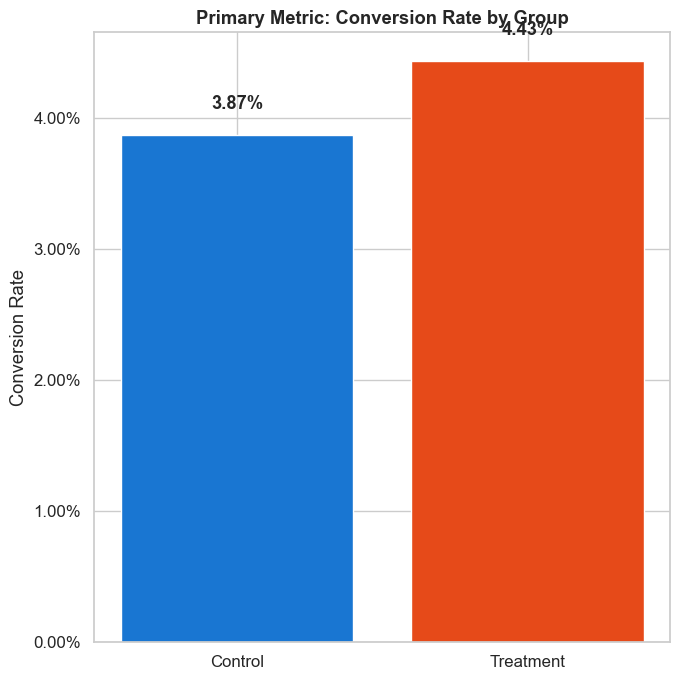

Abs diff: 0.565 pp
Rel lift: 14.60%
p-value : 0.1567
95% CI  : [-0.217, 1.347] pp


In [23]:
cvr_c = zres["cvr_control"]
cvr_t = zres["cvr_treatment"]

fig, ax = plt.subplots(figsize=(7, 7))
bars = ax.bar(["Control", "Treatment"], [cvr_c, cvr_t], color=["#1976d2", "#e64a19"], edgecolor="white")
ax.set_ylabel("Conversion Rate")
ax.set_title("Primary Metric: Conversion Rate by Group", fontweight="bold")
ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))

for b, v in zip(bars, [cvr_c, cvr_t]):
    ax.text(b.get_x() + b.get_width()/2, v + 0.002, f"{v:.2%}", ha="center", fontweight="bold")

plt.tight_layout()
plt.savefig(FIGURES_DIR / "m03_cvr_by_group.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"Abs diff: {zres['abs_diff']*100:.3f} pp")
print(f"Rel lift: {zres['rel_lift_pct']:.2f}%")
print(f"p-value : {zres['p_value']:.4f}")
print(f"95% CI  : [{zres['ci_low']*100:.3f}, {zres['ci_high']*100:.3f}] pp")

## Bootstrap Robustness Check

In [24]:
boot = ab.bootstrap_conversion_diff(
    df=df,
    group_col="GROUP",
    outcome_col="CONVERTED",
    control_label="control",
    treatment_label="treatment",
    n_bootstrap=10000,
    seed=42,
    alpha=0.05,
)

display(pd.DataFrame([{
    "mean_diff": boot["mean_diff"],
    "ci_lower": boot["ci_lower"],
    "ci_upper": boot["ci_upper"],
    "significant": boot["significant"],
}]))

,mean_diff,ci_lower,ci_upper,significant
0,0.005653,-0.002176,0.013458,False


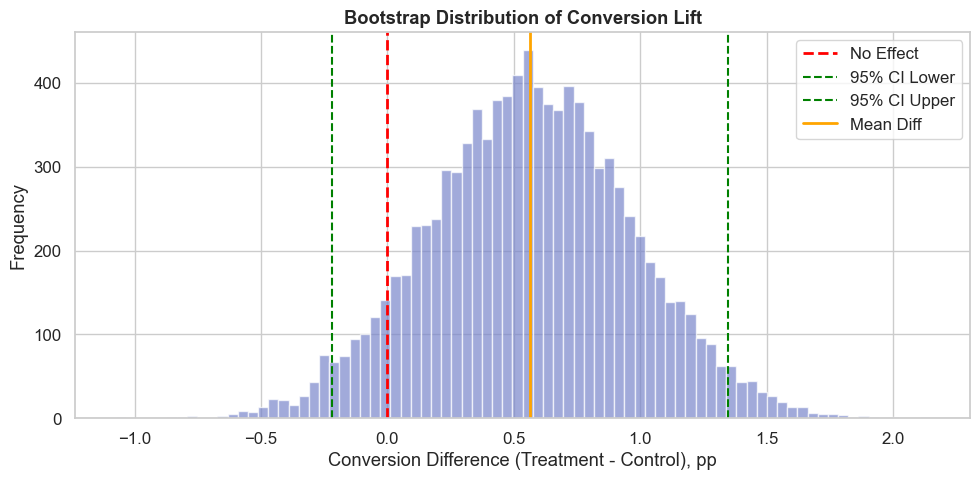

In [25]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(np.array(boot["bootstrap_diffs"]) * 100, bins=80, color="#7986cb", alpha=0.7, edgecolor="white")
ax.axvline(0, color="red", linestyle="--", linewidth=2, label="No Effect")
ax.axvline(boot["ci_lower"] * 100, color="green", linestyle="--", linewidth=1.5, label="95% CI Lower")
ax.axvline(boot["ci_upper"] * 100, color="green", linestyle="--", linewidth=1.5, label="95% CI Upper")
ax.axvline(boot["mean_diff"] * 100, color="orange", linewidth=2, label="Mean Diff")
ax.set_xlabel("Conversion Difference (Treatment - Control), pp")
ax.set_ylabel("Frequency")
ax.set_title("Bootstrap Distribution of Conversion Lift", fontweight="bold")
ax.legend()
plt.tight_layout()
plt.savefig(FIGURES_DIR / "m03_bootstrap_ci.png", dpi=150, bbox_inches="tight")
plt.show()

## Revenue Analysis

In [26]:
if "DISPLAY_PRICE" not in df.columns:
    raise ValueError("DISPLAY_PRICE column required for revenue analysis.")

x = df.copy()
x["DISPLAY_PRICE"] = pd.to_numeric(x["DISPLAY_PRICE"], errors="coerce").fillna(0.0)
x["REVENUE"] = np.where(x["CONVERTED"] == 1, x["DISPLAY_PRICE"], 0.0)

rev_summary = (
    x.groupby("GROUP", as_index=False)
    .agg(
        VISITORS=("CONVERTED", "size"),
        BOOKINGS=("CONVERTED", "sum"),
        REVENUE=("REVENUE", "sum"),
    )
)
rev_summary["CVR"] = rev_summary["BOOKINGS"] / rev_summary["VISITORS"]
rev_summary["RPV"] = rev_summary["REVENUE"] / rev_summary["VISITORS"]
rev_summary["AOV"] = np.where(rev_summary["BOOKINGS"] > 0, rev_summary["REVENUE"] / rev_summary["BOOKINGS"], np.nan)

display(rev_summary)

,GROUP,VISITORS,BOOKINGS,REVENUE,CVR,RPV,AOV
0,control,5015,194,62035.31,0.038684,12.369952,319.769639
1,treatment,4985,221,62579.74,0.044333,12.553609,283.166244


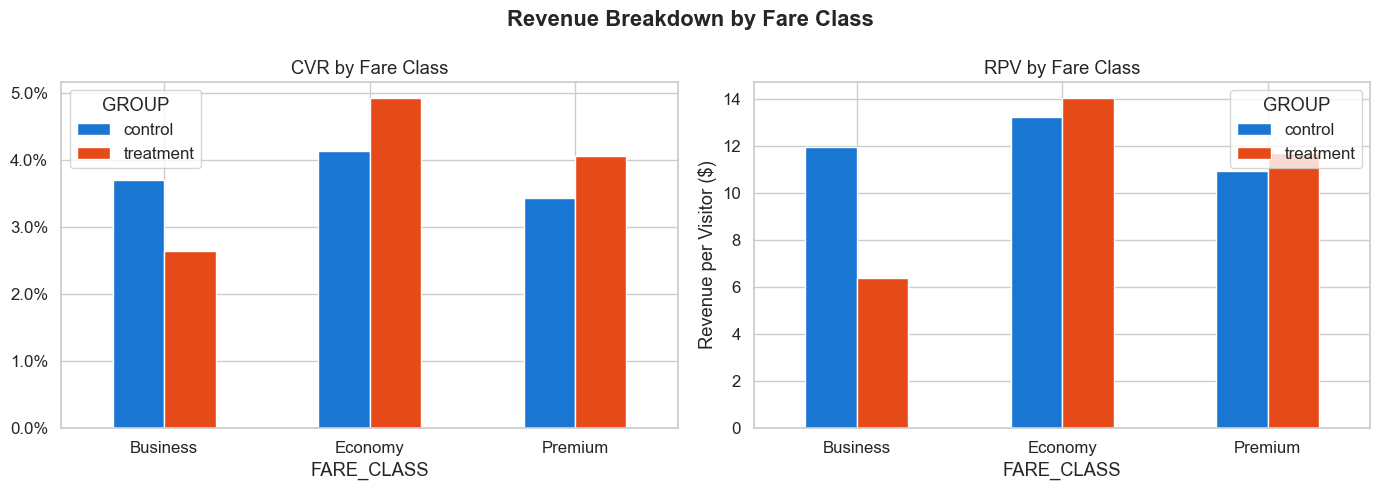

In [27]:
if "FARE_CLASS" in x.columns:
    rev_fare = (
        x.groupby(["FARE_CLASS", "GROUP"], as_index=False)
        .agg(
            VISITORS=("CONVERTED", "size"),
            BOOKINGS=("CONVERTED", "sum"),
            REVENUE=("REVENUE", "sum"),
        )
    )
    rev_fare["CVR"] = rev_fare["BOOKINGS"] / rev_fare["VISITORS"]
    rev_fare["RPV"] = rev_fare["REVENUE"] / rev_fare["VISITORS"]

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    rev_fare.pivot(index="FARE_CLASS", columns="GROUP", values="CVR").plot(kind="bar", ax=axes[0], rot=0, color=["#1976d2", "#e64a19"])
    axes[0].set_title("CVR by Fare Class")
    axes[0].yaxis.set_major_formatter(mtick.PercentFormatter(1.0))

    rev_fare.pivot(index="FARE_CLASS", columns="GROUP", values="RPV").plot(kind="bar", ax=axes[1], rot=0, color=["#1976d2", "#e64a19"])
    axes[1].set_title("RPV by Fare Class")
    axes[1].set_ylabel("Revenue per Visitor ($)")

    plt.suptitle("Revenue Breakdown by Fare Class", fontweight="bold")
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / "m03_revenue_by_fare.png", dpi=150, bbox_inches="tight")
    plt.show()
else:
    print("FARE_CLASS not present; skipped fare-level chart.")

## Segment Diagnostics 

In [28]:
segment_frames = []

for seg_col in ["FARE_CLASS", "TRAVELER_TYPE", "DEVICE"]:
    if seg_col in df.columns:
        seg_df = ab.segment_ab_analysis(
            df=df,
            segment_col=seg_col,
            group_col="GROUP",
            outcome_col="CONVERTED",
            control_label="control",
            treatment_label="treatment",
            min_n_per_arm=50,
            alpha=0.05,
        )
        seg_df["SEGMENT_TYPE"] = seg_col
        segment_frames.append(seg_df)

segments = pd.concat(segment_frames, ignore_index=True) if segment_frames else pd.DataFrame()
display(
    segments.style.map(
        lambda v: "background-color: #c8e6c9" if v is True else "background-color: #ffcdd2" if v is False else "",
        subset=["SIGNIFICANT"] if "SIGNIFICANT" in segments.columns else []
    )
)

,SEGMENT_VALUE,N_CONTROL,N_TREATMENT,CVR_CONTROL,CVR_TREATMENT,ABS_DIFF,RELATIVE_LIFT_PCT,P_VALUE,SIGNIFICANT,SKIP_REASON,SEGMENT_TYPE
0,Economy,2926,2965,0.041353,0.049241,0.007888,19.074046,0.145617,False,,FARE_CLASS
1,Premium,1575,1528,0.034286,0.040576,0.006290,18.346422,0.355776,False,,FARE_CLASS
2,Business,514,492,0.036965,0.026423,-0.010542,-28.519469,0.340871,False,,FARE_CLASS
3,leisure,2732,2768,0.038433,0.044798,0.006364,16.559317,0.237450,False,,TRAVELER_TYPE
4,business,1557,1478,0.036609,0.042625,0.006016,16.434015,0.395258,False,,TRAVELER_TYPE
5,family,726,739,0.044077,0.046008,0.001931,4.380920,0.858598,False,,TRAVELER_TYPE
6,desktop,1464,1576,0.031421,0.042513,0.011092,35.301258,0.106255,False,,DEVICE
7,mobile,3551,3409,0.041678,0.045175,0.003496,8.388368,0.474201,False,,DEVICE


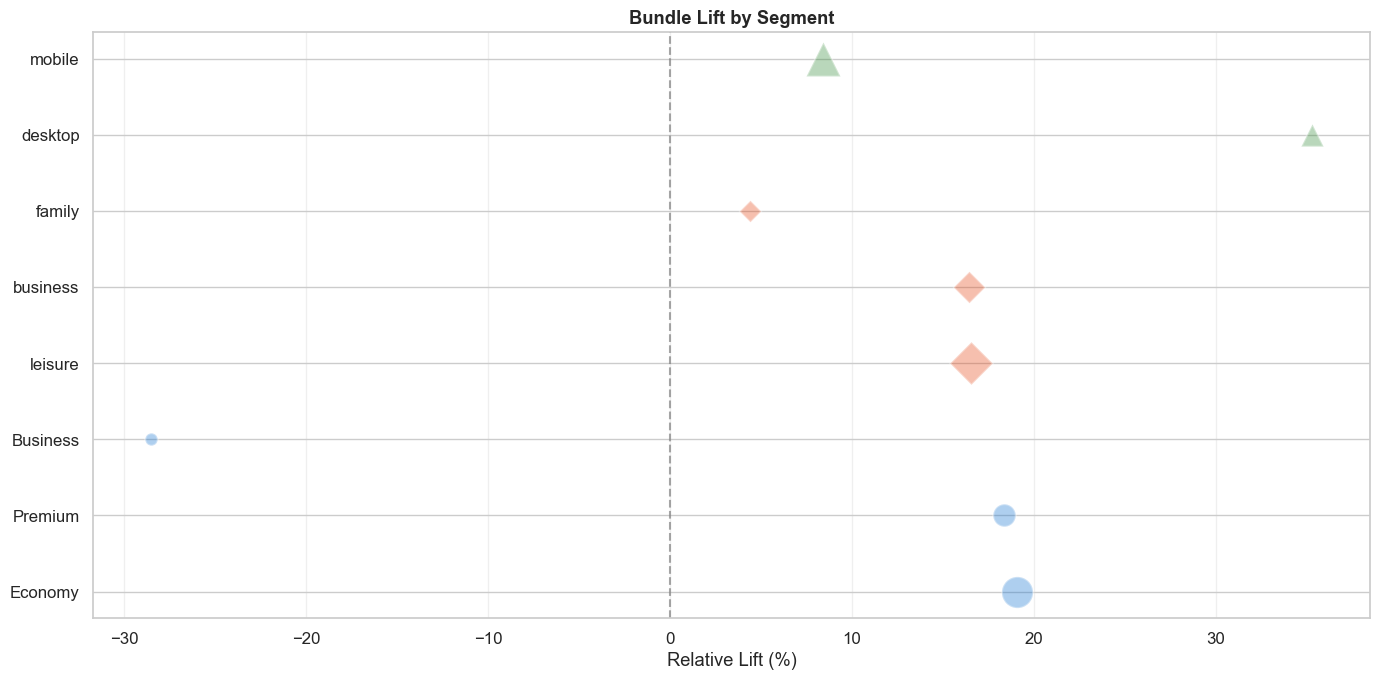

In [29]:
if not segments.empty:
    fig, ax = plt.subplots(figsize=(14, 7))

    style_map = {
        "FARE_CLASS": {"marker": "o", "color": "#1976d2"},
        "TRAVELER_TYPE": {"marker": "D", "color": "#e64a19"},
        "DEVICE": {"marker": "^", "color": "#388e3c"},
    }

    total_n = segments["N_CONTROL"] + segments["N_TREATMENT"]
    size_min, size_max = total_n.min(), total_n.max()
    bubble = 80 + (total_n - size_min) / (size_max - size_min + 1) * 520

    for seg_type in segments["SEGMENT_TYPE"].unique():
        sdf = segments[segments["SEGMENT_TYPE"] == seg_type]
        st = style_map.get(seg_type, {"marker": "o", "color": "#616161"})
        for _, r in sdf.iterrows():
            if pd.isna(r["RELATIVE_LIFT_PCT"]):
                continue
            ax.scatter(
                r["RELATIVE_LIFT_PCT"], r["SEGMENT_VALUE"],
                s=bubble.loc[r.name],
                marker=st["marker"],
                color=st["color"],
                alpha=1.0 if r["SIGNIFICANT"] else 0.35,
                edgecolors="white",
                linewidths=1.5,
            )

    ax.axvline(0, color="gray", linestyle="--", alpha=0.7)
    ax.set_xlabel("Relative Lift (%)")
    ax.set_title("Bundle Lift by Segment", fontweight="bold")
    ax.grid(axis="x", alpha=0.3)
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / "m03_segment_lift.png", dpi=150, bbox_inches="tight")
    plt.show()
else:
    print("No segment columns available for segment analysis.")

In [31]:
# Cell 21 (Code) — Save outputs
out = DATA_PROCESSED / "ab_test"
out.mkdir(parents=True, exist_ok=True)

summary.to_csv(out / "ab_summary.csv", index=False)
pd.DataFrame([srm]).to_csv(out / "srm_check.csv", index=False)
pd.DataFrame([zres]).to_csv(out / "ztest_result.csv", index=False)
pd.DataFrame([{
    "mean_diff": boot["mean_diff"],
    "ci_lower": boot["ci_lower"],
    "ci_upper": boot["ci_upper"],
    "significant": boot["significant"],
}]).to_csv(out / "bootstrap_result.csv", index=False)
rev_summary.to_csv(out / "revenue_summary.csv", index=False)
if "rev_fare" in locals():
    rev_fare.to_csv(out / "revenue_by_fare.csv", index=False)
if not segments.empty:
    segments.to_csv(out / "segment_analysis.csv", index=False)
if not seq.empty:
    seq.to_csv(out / "sequential_monitoring.csv", index=False)

print(f"Outputs saved to: {out}")
print(f"Figures saved to: {FIGURES_DIR}")

Outputs saved to: C:\repos\Travel\OTA-Growth-Analytics-NYC-Dubai\data\processed\ab_test
Figures saved to: C:\repos\Travel\OTA-Growth-Analytics-NYC-Dubai\outputs\figures
